# 환경설정

In [ ]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.ERROR)
# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)

# ── 스타일 설정 ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'NanumBarunGothic',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.unicode_minus': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 110,
})

# 경사하강법

## 1. 도함수의 정의와 계산 (기울기 도출)

- **강의 4, 7페이지:** 특정 점에서의 순간적인 변화율을 구하는 미분의 정의 극한값 $\lim_{h\to 0}\frac{f(x+h)-f(x)}{h} = f'(x)$ 이 등장합니다. 또한 복잡한 함수는 연쇄법칙(Chain rule) 등을 통해 계산할 수 있습니다.


- **코드 적용:** 손실함수 $L(w)$를 미분 공식을 통해 직접 계산하여 `dL(w)` 함수를 정의합니다. 이는 현재 가중치($w$) 지점에서 함수가 어느 방향으로 얼마나 기울어져 있는지(접선의 기울기)를 산출하는 과정입니다.

## 2. 테일러 급수와 접선의 방정식 (1차 근사)

- **강의 13, 15페이지:** 함수를 무한한 다항식의 합으로 표현하는 테일러 급수 $f(x) = f(x^*) + f'(x^*)(x-x^*) + \frac{f''(x^*)}{2!}(x-x^*)^2 + \cdots$ 이론이 설명되어 있습니다.

- **코드 적용:** 코드에서 접선을 그리는 수식은 위 테일러 급수에서 2차 이상의 항을 생략한 **1차 테일러 근사** 식인 $f(x) \approx f(x^*) + f'(x^*)(x-x^*)$ 와 완벽히 동일합니다.

## 3. 경사하강법의 이동 규칙 (오차 감소 원리)

- **강의 15페이지 (응용):** 테일러 전개식의 원리에 따라, 1차 근사식에 이동 거리 $x - x^* = -\eta f'(x^*)$ 를 대입하면 $f(x) \approx f(x^*) - \eta f'(x^*)^2$ 가 됩니다.

- **코드 적용:** 도함수의 제곱은 항상 양수이므로, 기울기의 **반대 방향**으로 이동($-\eta$)하면 결과적으로 함수값(손실)이 항상 줄어든다는 것을 수학적으로 보장합니다.

## 4. 학습률(Learning Rate)과 발산 현상

- **강의 32페이지:** 테일러 전개식에는 유효성을 결정짓는 나머지 항 $R_n$ 이 존재합니다.
- **코드 적용:** 학습률($\eta$)이 너무 커서 이동 거리가 멀어지면, 생략했던 2차 이상의 테일러 나머지 항의 영향력이 커집니다. 이로 인해 1차 근사(접선)가 실제 함수 곡선과 크게 빗나가게 되어 오차가 줄어들지 않고 오히려 발산(진동)하게 됩니다.

## 5. 최적화 종료와 임계점 (수렴)

- **강의 21, 22페이지:** 함수가 미분 가능할 때 $f'(x^*) = 0$ 이 되는 지점을 임계점(critical point)이라고 부릅니다. 전체 구간에서 가장 작은 값을 가지면 전역최소자, 주변 구간에서 가장 작으면 국소최소자입니다. (22페이지에 그래프로 제시되어 있습니다 ).

- **코드 적용:** 경사하강법을 반복하여 접선의 기울기가 **0**에 한없이 가까워지는 임계점에 도달하면 업데이트가 멈춥니다. 시작 위치에 따라 각기 다른 골짜기(국소 최소자 또는 전역 최소자)의 임계점에 수렴하게 됩니다.

## 6. 2차 미분 테스트와 최적 학습률 (뉴턴법)

- **강의 17, 18, 24페이지:** $f''(x^*) > 0$ 이면 해당 지점에서 최솟값을 갖는다는 2차 미분 테스트 이론과 최대최소이론이 등장합니다.

- **코드 적용:** 이처럼 곡선의 휘어짐 정도(곡률)를 나타내는 2차 미분값 $f''(w)$ 을 활용하면, 곡률이 가파를 때는 조금씩, 완만할 때는 크게 이동하도록 학습률을 자동으로 조절하는 발전된 알고리즘(뉴턴법)을 설계할 수 있습니다.


## 핵심 요약 테이블 (강의 페이지 포함)

| 강의 자료 수학 이론 | 참고 페이지 | 경사하강법 알고리즘 | 시각화 / 코드 의미 |
| --- | --- | --- | --- |
| **도함수 정의 ($f'(x)$)** | **4, 7p** | **기울기 산출 (`dL`)** | 현재 상태의 가파름과 방향을 측정 |
| **1차 테일러 근사** | **13, 15p** | **접선 그리기 (`y_tan`)** | 근접한 범위 내에서의 변화량 예측 |
| **기울기 역방향 이동** | **15p** (응용) | **파라미터 업데이트** | 오차가 반드시 줄어드는 방향으로 한 걸음 이동 |
| **테일러 나머지 항 ($R_n$)** | **32p** | **학습률 (`lr`) 조절** | 1차 근사가 유효한 '안전한 보폭'의 한계선 |
| **임계점 ($f'(x^*)=0$)** | **21, 22p** | **최적화 수렴점** | 더 이상 오차가 줄어들지 않는 최적의 가중치 |
| **2차 미분 ($f''(x)>0$)** | **17, 18, 24p** | **뉴턴법 (자동 보폭)** | 곡률을 계산하여 가장 이상적인 학습률 크기 추정 |

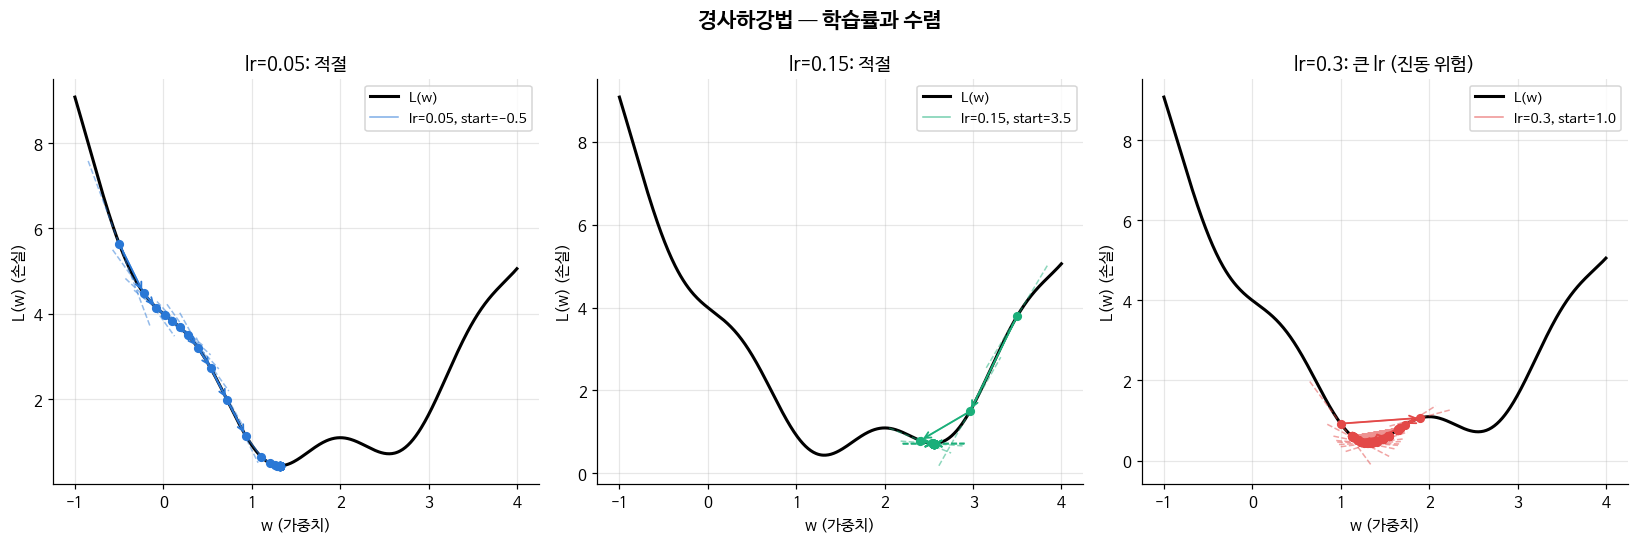

핵심 요약:
• lr 너무 작 → 수렴 느림   (테일러 1차 근사 유효 범위 내)
• lr 적당   → 안정 수렴   (2차 미분으로 최적 lr 추정 가능: Newton's method)
• lr 너무 큼 → 발산/진동  (테일러 근사 무효 구간 초과)


In [ ]:
# 코드 작성

# 총 정리
# 강의자료 챕터별 3중 의미 정리

## 1. 도함수의 정의 (10.1-1)
- **수학적 의미**: $f'(x) = \lim_{h\to0}\frac{f(x+h)-f(x)}{h}$ — 한 점에서의 순간 변화율, 즉 그래프의 접선 기울기


## 2. 미분의 법칙 & 연쇄법칙 (10.1-2, 10.1-3)
- **수학적 의미**: 덧셈·상수곱·곱셈·나눗셈 규칙, 그리고 합성함수 $u(x)=g(f(x))$의 미분 $u'(x)=g'(f(x))f'(x)$


## 3. 고차 도함수 (10.1-4)
- **수학적 의미**: $f''(x)$는 곡률(휘어짐)을, $f^{(n)}(x)$는 함수의 미세한 구조를 나타냄


## 4. 평균값 정리 (10.1-5)
- **수학적 의미**: 구간 $[a,b]$에서 평균 변화율과 같은 순간 변화율을 갖는 점 $c$가 반드시 존재

## 5. 테일러 급수 (10.2-1, 10.3-1~4)
- **수학적 의미**: 복잡한 함수를 $x^*$ 근처에서 다항식(1차+2차+3차+...)으로 근사. 1차만 쓰면 접선, 2차까지 쓰면 포물선 근사


## 6. 2차 미분 테스트 & 최소자/임계점 (10.2-2, 10.2-3, 10.2-4)
- **수학적 의미**: $f'(x^*)=0$(임계점)이고 $f''(x^*)>0$이면 국소 최소자, $f''(x^*)<0$이면 국소 최대자

## 7. 테일러 급수의 잔여항과 수렴 (10.3-2, 10.3-3)
- **수학적 의미**: 무한 급수로 갈 때 남는 오차항 $R_n = \frac{f^{(n)}(c)}{n!}(x-x^*)^n$이 0으로 수렴해야 근사가 정당화됨
